# [IAPR][iapr]: Final project - Chocolate Recognition


**Moodle group ID:** *xx*  
**Kaggle challenge:** *xx* (either `Classic` or `Deep learning`)  
**Kaggle team name (exact):** "*xx*"  

**Author 1 (SCIPER):** *Student Name 1 (xxxxx)*  
**Author 2 (SCIPER):** *Student Name 2 (xxxxx)*  
**Author 3 (SCIPER):** *Student Name 3 (xxxxx)*  

**Due date:** 21.05.2025 (11:59 pm)


## Key Submission Guidelines:
- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`
- **Only groups of three will be accepted**, except in exceptional circumstances.


[iapr]: https://github.com/LTS5/iapr2025

---

> Your comments  
> ...

# TORCH WORK

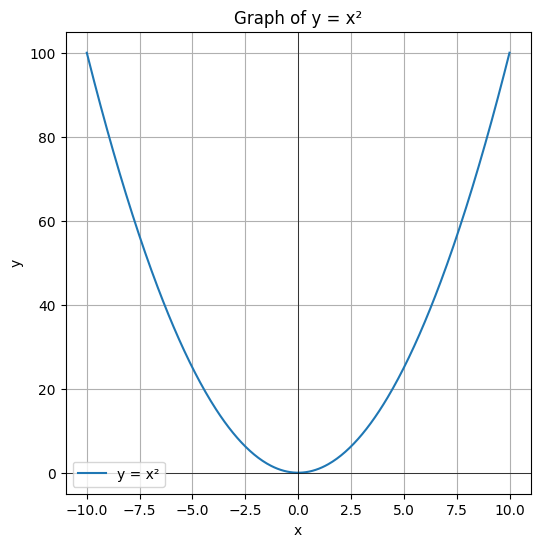

In [4]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(-10, 10, 400)
y = x ** 2
plt.figure(figsize=(6, 6))
plt.plot(x, y, label='y = x²')
plt.title('Graph of y = x²')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

In [1]:
from src.utils import YoloGridDataset, print_total_paramters, train_model, use_model_on_images_with_nms, use_model_on_image_with_nms_by_name, create_controller_csv, evaluate_f1_score,create_table_from_pt_nms
import pandas as pd
from src.models import YOLOv8Lite, TinyYOLO, CompactYOLOv2
from pathlib import Path
import os
import torch
from torch.utils.data import DataLoader
import numpy as np

In [2]:

IMG_PARAM = {}
IMG_PARAM["IMG_SIZE"] = 640
IMG_PARAM["ANCHOR"] = 3
IMG_PARAM["NUM_CLASSES"] = 13

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = YOLOv8Lite().to(device)

if(isinstance(model,TinyYOLO) or isinstance(model,CompactYOLOv2)):
    IMG_PARAM["GRID_SIZE"] = 20
elif(isinstance(model,YOLOv8Lite)):
    IMG_PARAM["GRID_SIZE"] = 40


current_dir = os.getcwd()
train_root_dir = Path(f'{current_dir}/data/train')

# Use in your dataset
train_dataset = YoloGridDataset(
    root_dir=train_root_dir,
    GRID_SIZE=IMG_PARAM["GRID_SIZE"],
    image_size=(IMG_PARAM["IMG_SIZE"], IMG_PARAM["IMG_SIZE"])
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 20
name_of_saved_pt = "YoloV8LiteAugmentedData"


test_root_dir = Path(f'{current_dir}/data/test')

test_dataset = YoloGridDataset(
    root_dir=test_root_dir,
    GRID_SIZE=IMG_PARAM["GRID_SIZE"],
    image_size=(IMG_PARAM["IMG_SIZE"], IMG_PARAM["IMG_SIZE"])
)

test_loader = DataLoader(test_dataset, batch_size=2, shuffle=True)

In [3]:

print_total_paramters(model)

Total Parameters: 10,227,126


In [4]:
model_save_path = f"{current_dir}/model_weights"
train_model(model=model, total_epochs=EPOCHS, optimizer=optimizer, device=device, 
            per_epoch_save=4, train_loader=train_loader, test_loader=test_loader, plotting_callback=None, 
            name_of_saved_pt=name_of_saved_pt, pt_save_path=model_save_path)

Epoch 2/20:   5%|▌         | 1/20 [00:19<06:03, 19.12s/it]                                   

New best loss: 121.4605
Best model saved to: C:\Users\MSII\Desktop\EPFL_2semester\Image analysis and Pattern Recognition\EE-451\project/model_weights/YoloV8LiteAugmentedData_best.pt
Epoch 1/20, Total Loss: 121.4605


Epoch 3/20:  10%|█         | 2/20 [00:36<05:27, 18.18s/it]

New best loss: 62.8618
Best model saved to: C:\Users\MSII\Desktop\EPFL_2semester\Image analysis and Pattern Recognition\EE-451\project/model_weights/YoloV8LiteAugmentedData_best.pt
Epoch 2/20, Total Loss: 62.8618


Epoch 4/20:  15%|█▌        | 3/20 [00:54<05:04, 17.94s/it]

...

Epoch 18/20, Total Loss: 7.9327


Epoch 20/20:  95%|█████████▌| 19/20 [05:28<00:17, 17.17s/it]

Epoch 19/20, Total Loss: 4.9180


Model saved to: C:\Users\MSII\Desktop\EPFL_2semester\Image analysis and Pattern Recognition\EE-451\project/model_weights/YoloV8LiteAugmentedData_20.pt
New best loss: 3.4293
Best model saved to: C:\Users\MSII\Desktop\EPFL_2semester\Image analysis and Pattern Recognition\EE-451\project/model_weights/YoloV8LiteAugmentedData_best.pt
Epoch 20/20, Total Loss: 3.4293


YOLOv8Lite(
  (stem): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
    )
    (1): C2F(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (blocks): Sequential(
        (0): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU()
        )
        (1): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU()
        )
      )
      (out_conv): Sequential(
        (0): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1))
        (1): 

In [ ]:
model_weights_path = f"{current_dir}/model_weights"

# Load the model only once
model = YOLOv8Lite()
model.load_state_dict(torch.load(f"{model_weights_path}/CURRENT_BEST.pt", map_location=torch.device("cpu")))

# Run inference
data_root_dir = Path(f'{current_dir}/data/')
use_model_on_images_with_nms(root_dir=data_root_dir, number_of_images=180, model=model, IMG_PARAM=IMG_PARAM, conf_threshold=0.13, min_dist=40.0)



Input is a list of paths.


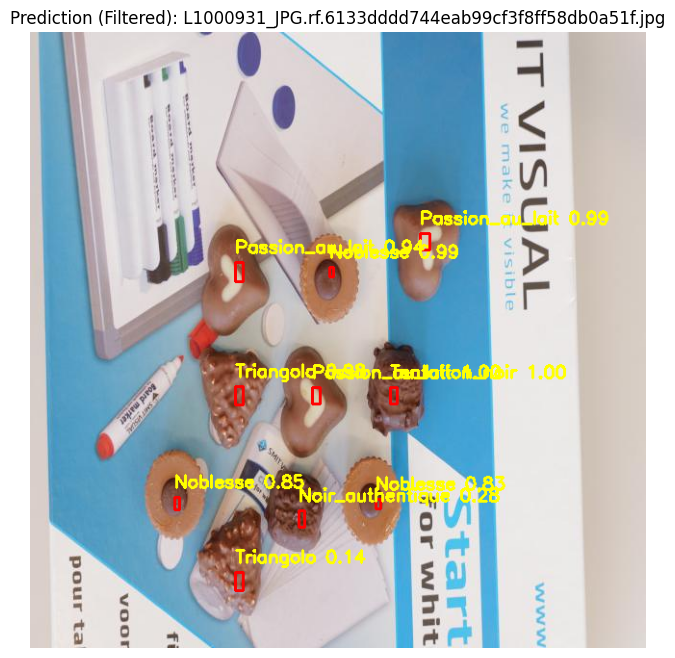

In [30]:
# Load the model only once
model = YOLOv8Lite()
model.load_state_dict(torch.load("model_weights/CURRENT_BEST.pt", map_location=torch.device("cpu")))

test_root_dir = Path(f'{current_dir}/data/test')
images = ["L1000931.jpg"]
use_model_on_image_with_nms_by_name(root_dir=test_root_dir, image_names=images, model=model, IMG_PARAM=IMG_PARAM, conf_threshold=0.1)


In [ ]:
create_controller_csv()

In [ ]:
evaluate_f1_score(pd.read_csv("DoNotSubmitThis_Controller/controller.csv"))

In [ ]:
# list_of_threshold = np.array(range(25))*0.01
# list_of_model_names = ["YOLOv8Lite_epoch100.pt","YOLOv8Lite_epoch200.pt","YOLOv8Lite_epoch300.pt"]

# list_of_threshold = np.array(range(0,6))*0.02
list_of_threshold = np.array(range(1,14))*0.01
list_of_model_names = ["YoloV8LiteAugmentedData200.pt"]
test_root_dir = Path(f'{current_dir}/data/test')
#epoch 200 conf 13 dist 40 -> 85

for model_name in list_of_model_names:
    for threshold in list_of_threshold:
        df = create_table_from_pt_nms(data_root_dir=test_root_dir, 
                                      model_path=f"{current_dir}/model_weights/{model_name}",
                                      model_class=YOLOv8Lite,
                                      IMG_PARAM=IMG_PARAM,
                                      conf_threshold=threshold,
                                      min_dist=40)
        print(f"Score for model {model_name}")
        evaluate_f1_score(df)

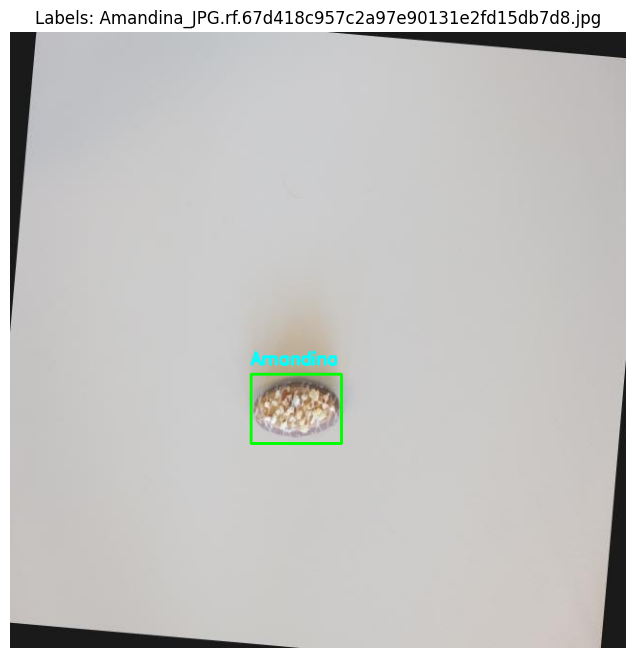

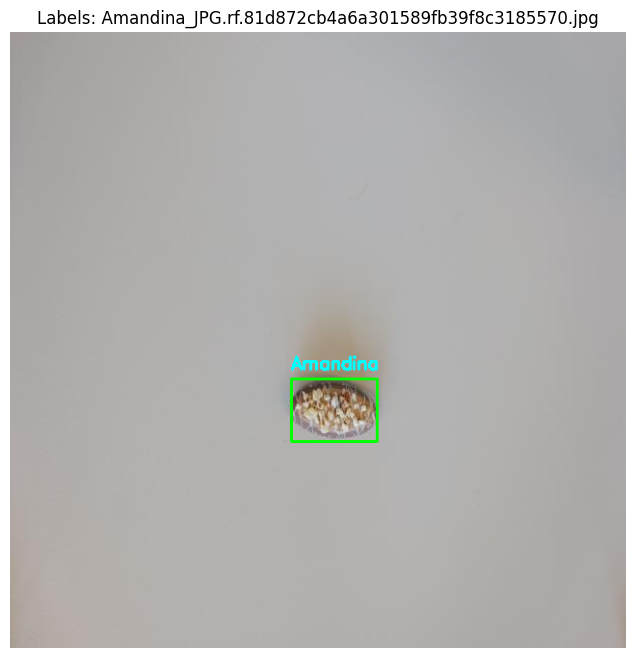

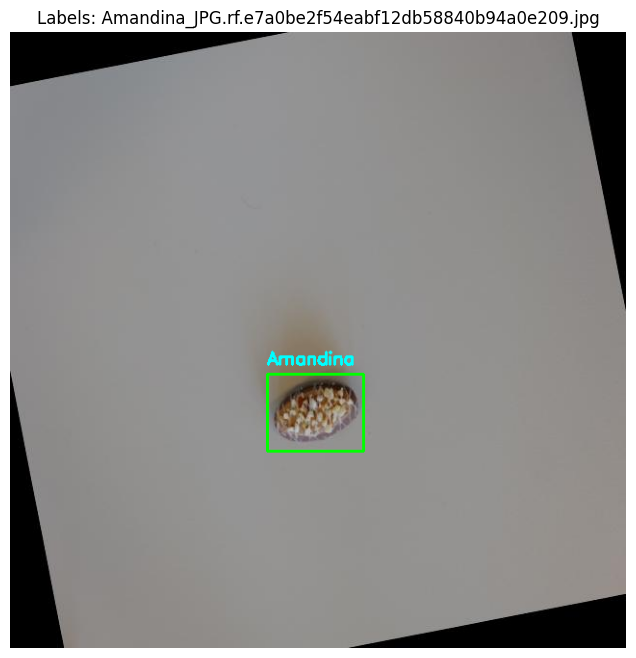

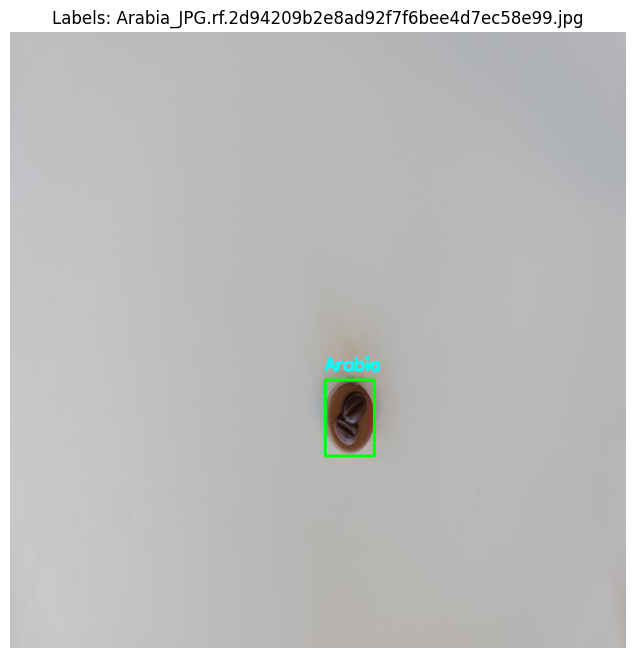

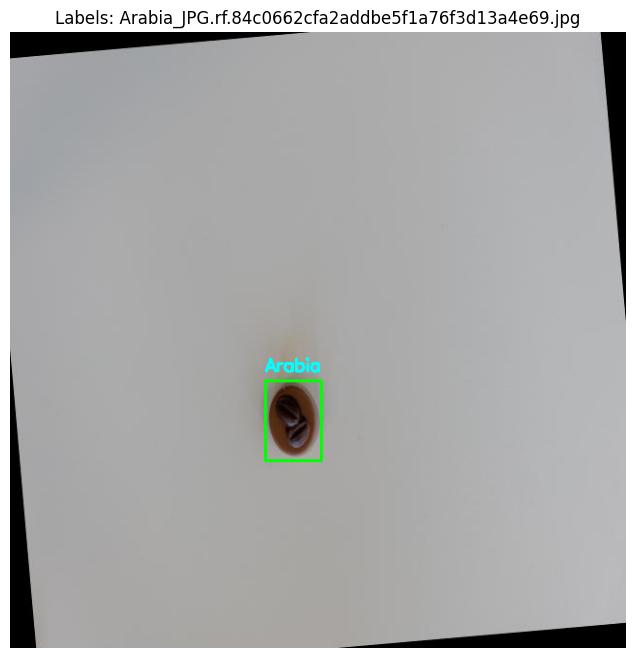

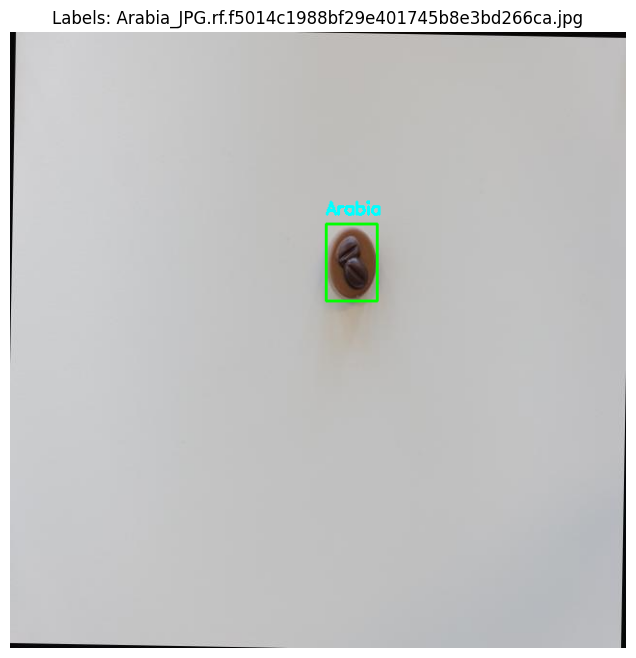

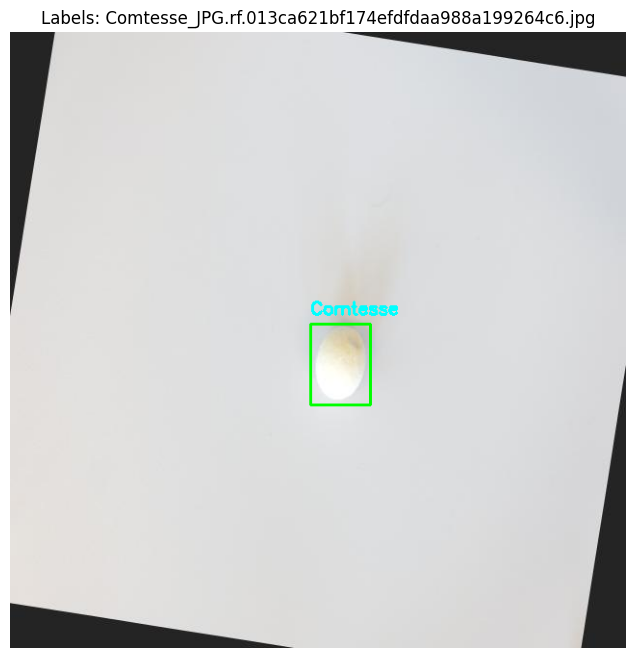

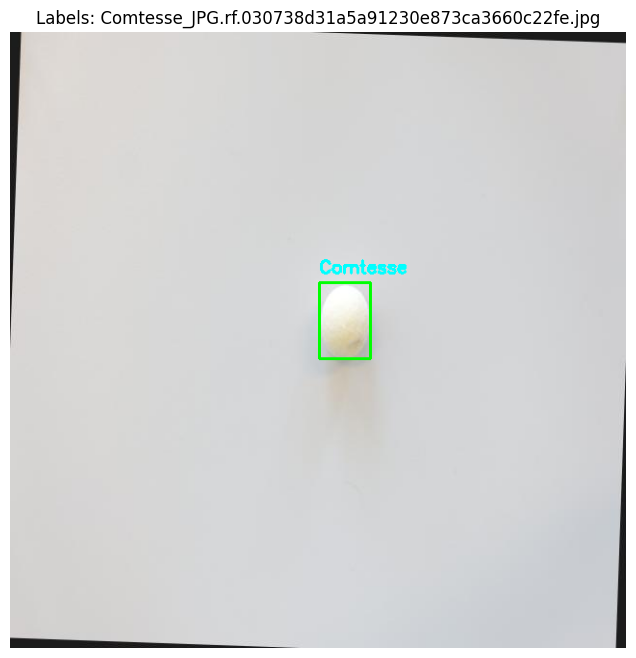

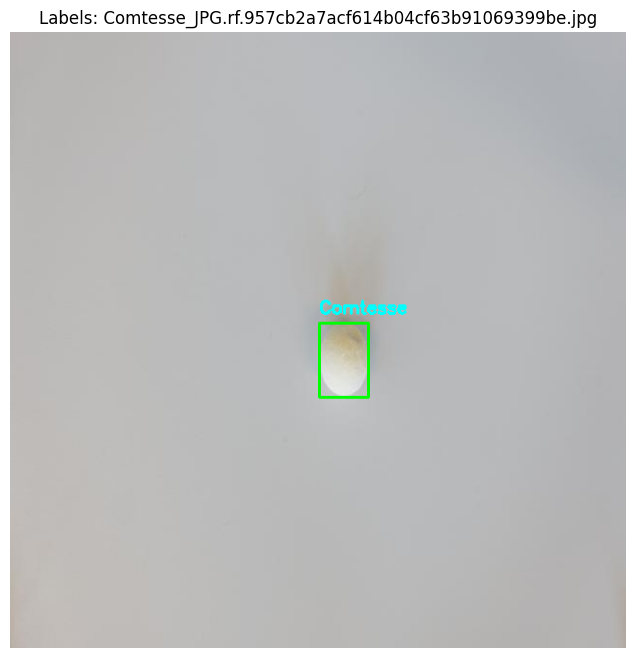

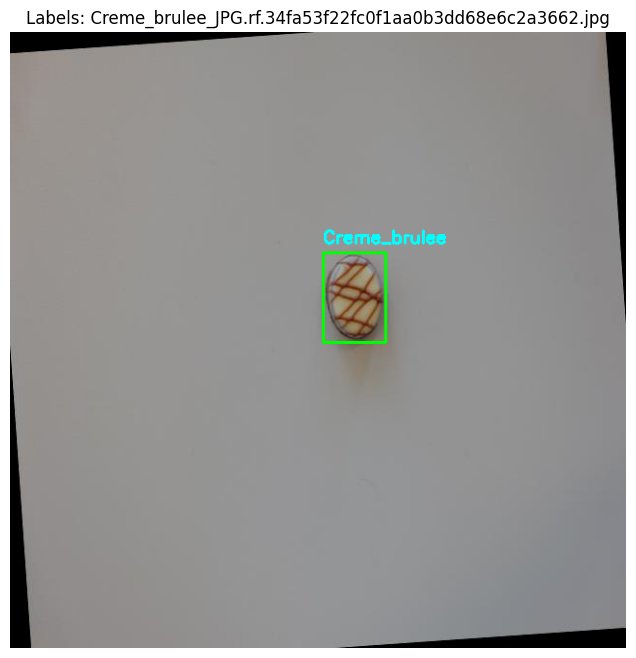

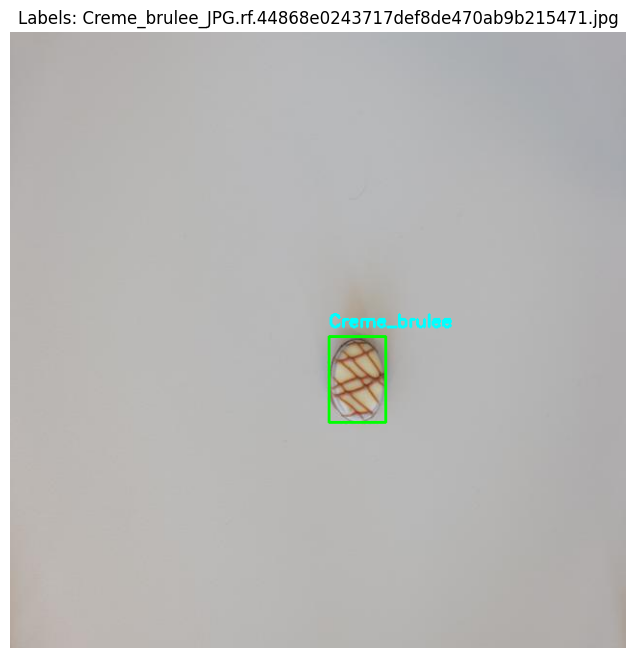

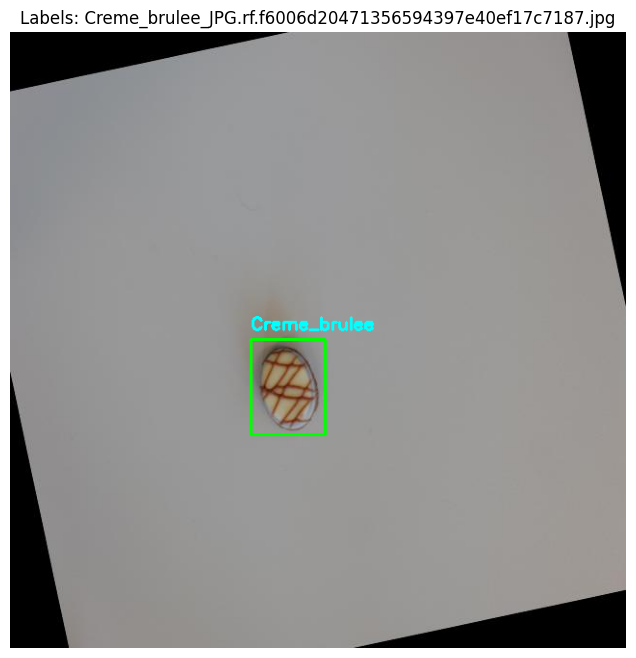

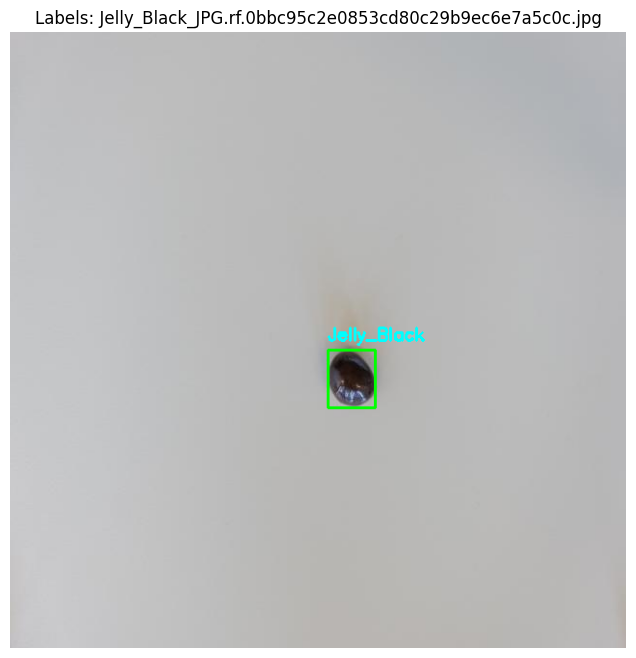

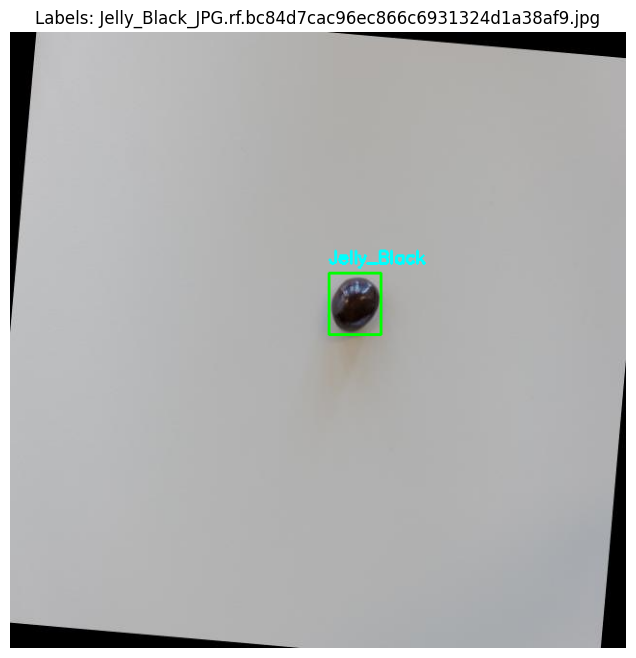

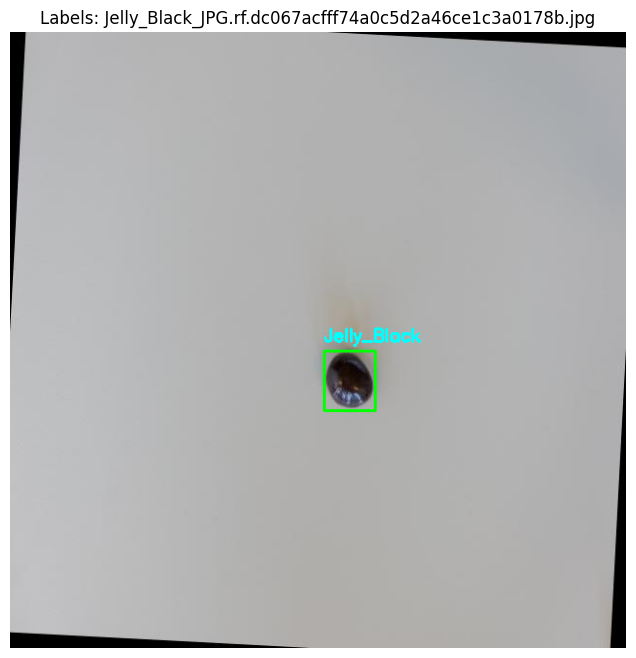

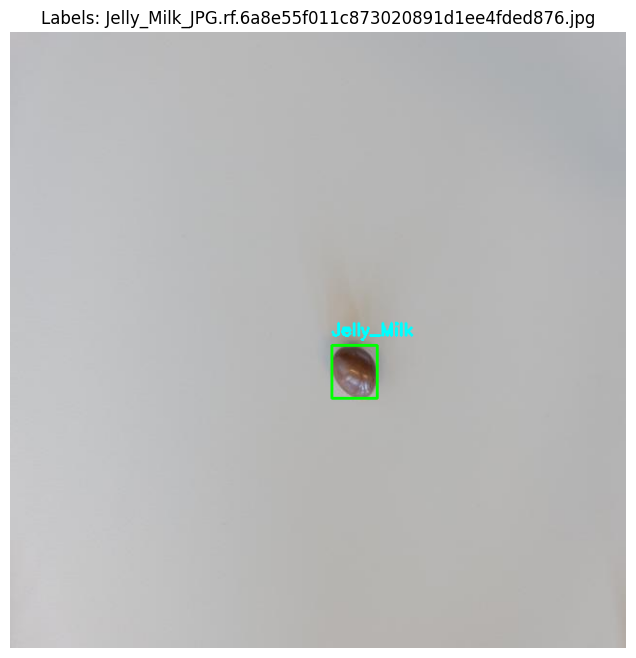

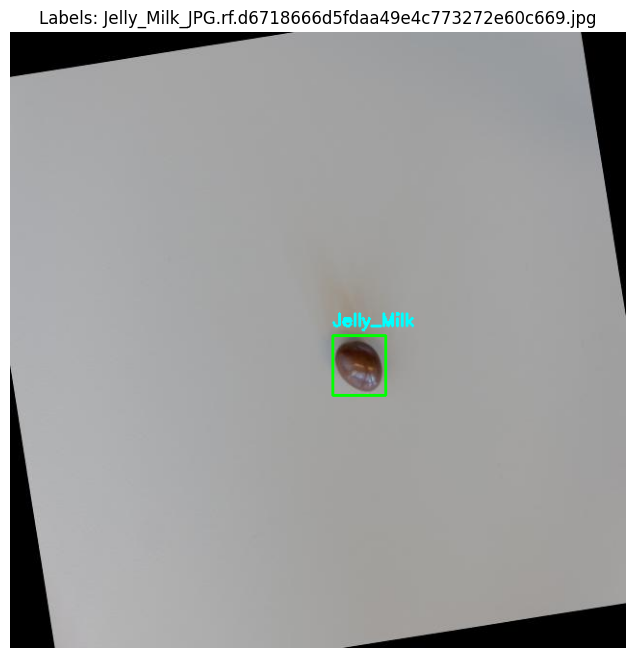

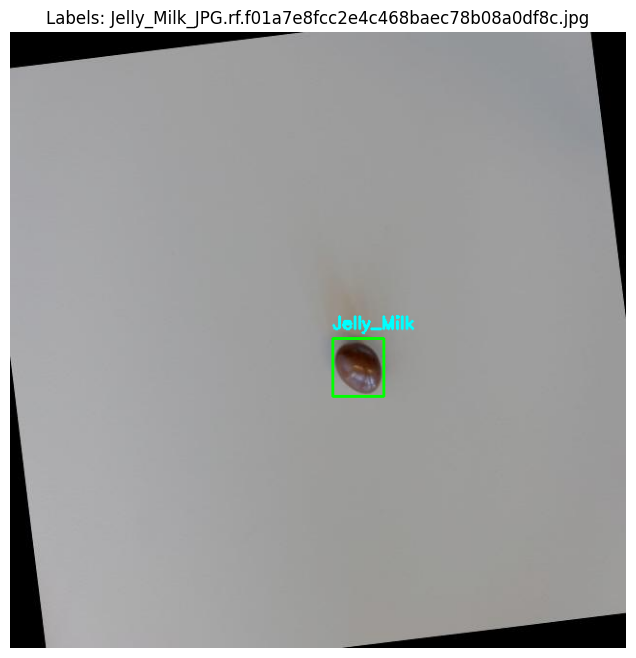

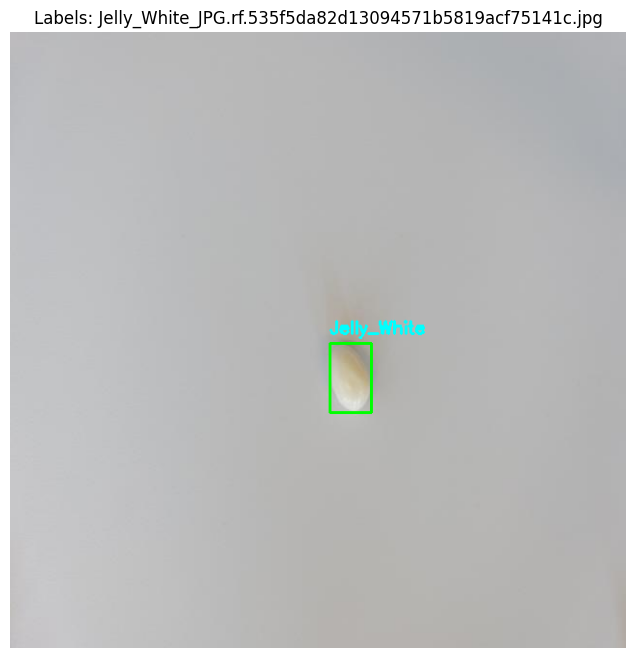

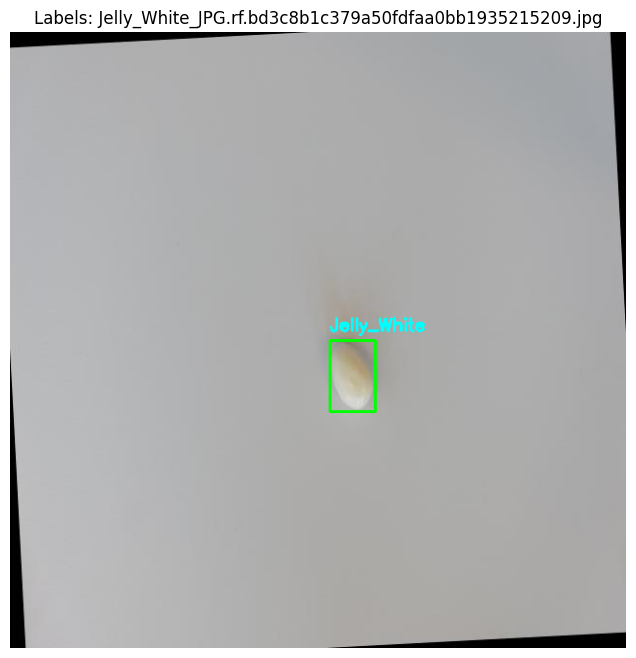

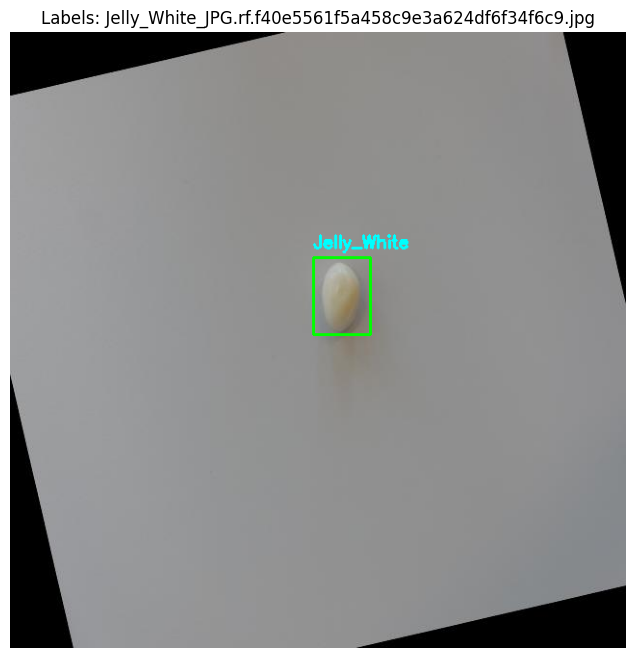

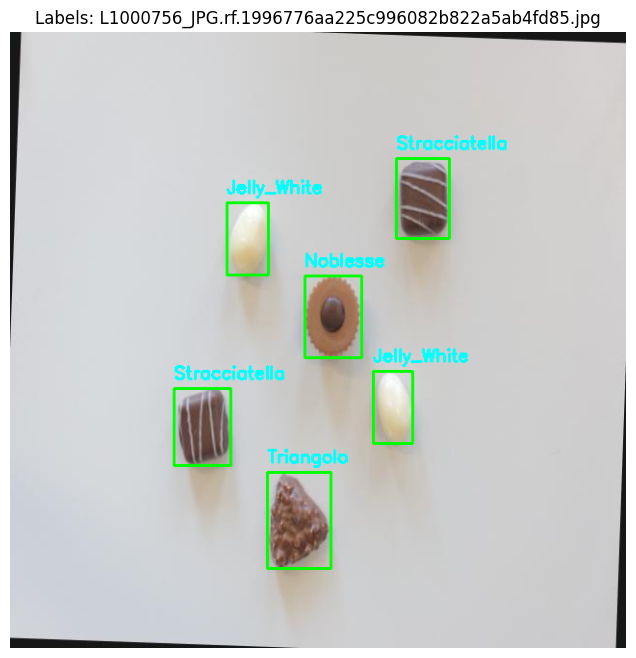

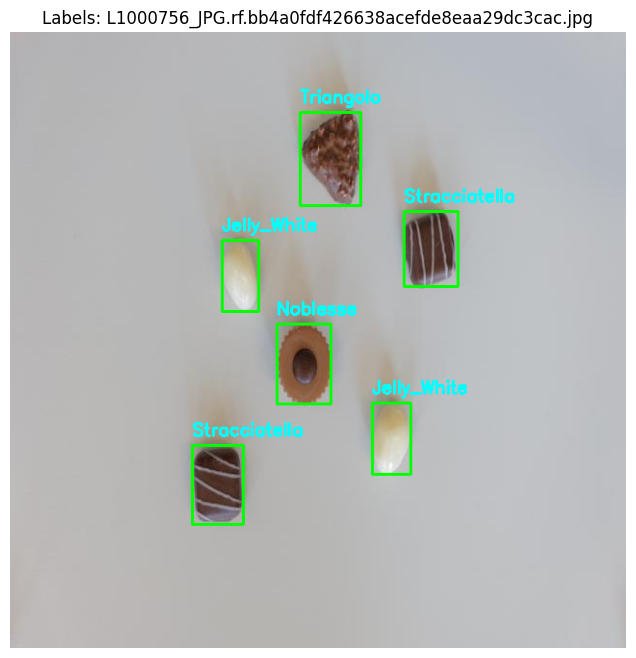

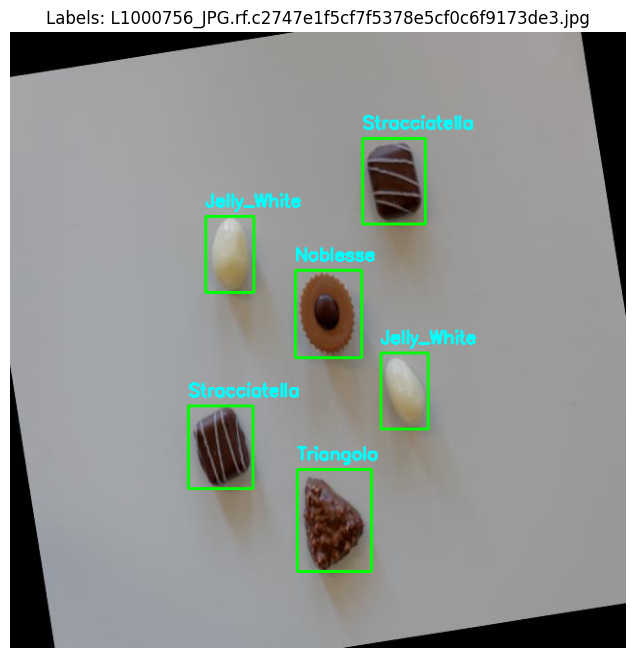

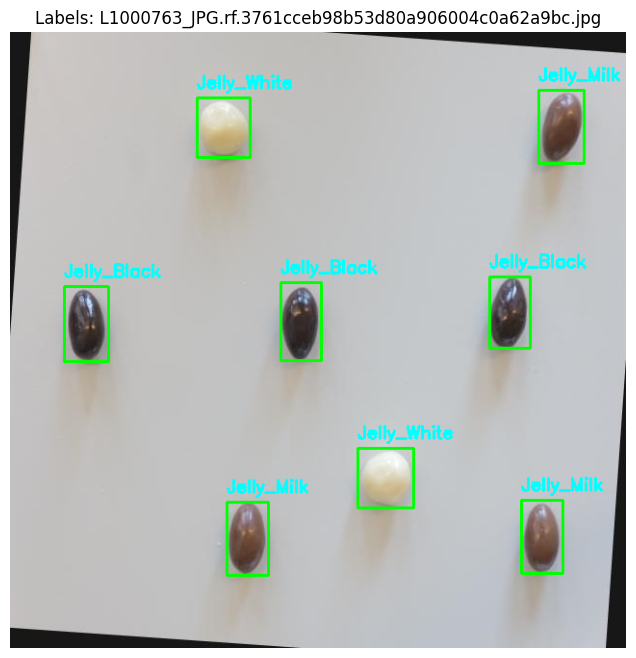

In [3]:
import os
import cv2
import matplotlib.pyplot as plt

# Your classes in order (matching YOLO IDs)
CLASS_NAMES = ['Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 'Jelly_Black',
               'Jelly_Milk', 'Jelly_White', 'Noblesse', 'Noir_authentique',
               'Passion_au_lait', 'Stracciatella', 'Tentation_noir', 'Triangolo']

# Paths
image_dir = "data/train/images"
label_dir = "data/train/labels"

# Get some image filenames
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))]
image_files = image_files[:25]  # Show only first 5 for example

for image_file in image_files:
    image_path = os.path.join(image_dir, image_file)
    label_path = os.path.join(label_dir, image_file.replace('.jpg', '.txt').replace('.png', '.txt'))

    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    if not os.path.exists(label_path):
        print(f"No label found for {image_file}")
        continue

    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x, y, box_w, box_h = map(float, line.strip().split())

            # Convert from relative to absolute coords
            x1 = int((x - box_w / 2) * w)
            y1 = int((y - box_h / 2) * h)
            x2 = int((x + box_w / 2) * w)
            y2 = int((y + box_h / 2) * h)

            class_name = CLASS_NAMES[int(cls)]

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, class_name, (x1, max(y1 - 10, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title(f"Labels: {image_file}")
    plt.axis('off')
    plt.show()

In [39]:
import torch
from src.models.YOLOv8Lite import YOLOv8Lite  # Ensure the path matches your project structure

# Instantiate the model with the correct number of classes
model = YOLOv8Lite(num_classes=13)
model.eval()

# Load weights from the checkpoint
model_weights_path = current_dir + "/model_weights/CURRENT_BEST.pt"  # Change this path
model.load_state_dict(torch.load(model_weights_path, map_location='cpu'))

print("Model loaded successfully!")


Model loaded successfully!


In [40]:
from PIL import Image
import torchvision.transforms as transforms

# Path to the image you want to visualize
image_path = current_dir + "/data/test/images/L1000757_JPG.rf.09c4b094eb5c4374391220cd23f4dad4.jpg"  # Change this path
image = Image.open(image_path).convert("RGB")

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((640, 640)),  # Resize to model input size
    transforms.ToTensor(),          # Convert to Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalization
                         std=[0.229, 0.224, 0.225])
])

# Apply transformations and add batch dimension
image_tensor = transform(image).unsqueeze(0)

print("Image loaded and transformed!")

Image loaded and transformed!


In [41]:
# Create a dictionary to store the features
feature_maps = {}

# Define a hook function
def hook_fn(module, input, output):
    feature_maps[module] = output

# Register hooks on desired layers
model.neck[0].register_forward_hook(hook_fn)  # SPPF Layer
model.head.register_forward_hook(hook_fn)     # Head Layer

print("Hooks registered!")

Hooks registered!


In [42]:
# Perform forward pass
with torch.no_grad():
    _ = model(image_tensor)

# Extracted feature maps
sppf_features = feature_maps[model.neck[0]]
head_features = feature_maps[model.head]

print(f"SPPF Features Shape: {sppf_features.shape}")
print(f"Head Features Shape: {head_features.shape}")

SPPF Features Shape: torch.Size([1, 512, 40, 40])
Head Features Shape: torch.Size([1, 54, 40, 40])


Visualizing SPPF Layer Features:


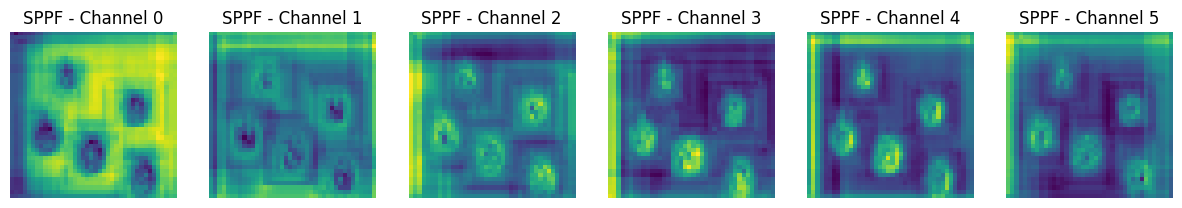

Visualizing Head Layer Features:


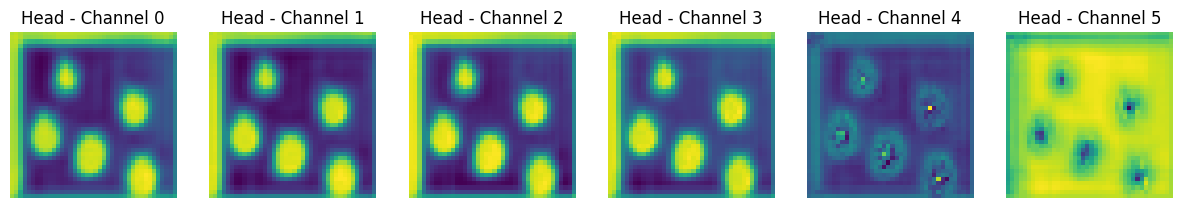

In [43]:
import matplotlib.pyplot as plt

def visualize_feature_map(feature_map, layer_name, num_images=6):
    """
    Visualizes a given feature map.
    """
    num_channels = feature_map.shape[1]
    plt.figure(figsize=(15, 10))
    
    # Select channels to visualize
    for i in range(min(num_images, num_channels)):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(feature_map[0, i].detach().cpu().numpy(), cmap='viridis')
        plt.title(f"{layer_name} - Channel {i}")
        plt.axis('off')
    plt.show()

# Visualize features
print("Visualizing SPPF Layer Features:")
visualize_feature_map(sppf_features, "SPPF")

print("Visualizing Head Layer Features:")
visualize_feature_map(head_features, "Head")

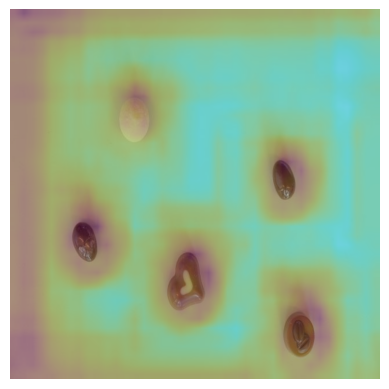

In [44]:
import cv2
import numpy as np

def overlay_feature_on_image(image_path, feature_map, channel=0, alpha=0.5):
    """
    Overlay a specific feature map channel on the original image.
    """
    # Read the original image
    original_image = cv2.imread(image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # Resize feature map to image size
    feature = feature_map[0, channel].detach().cpu().numpy()
    feature = cv2.resize(feature, (original_image.shape[1], original_image.shape[0]))

    # Normalize feature map for visualization
    feature = (feature - feature.min()) / (feature.max() - feature.min())
    heatmap = np.uint8(255 * feature)

    # Apply color map
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_VIRIDIS)

    # Overlay heatmap on original image
    overlayed_image = cv2.addWeighted(heatmap, alpha, original_image, 1 - alpha, 0)
    plt.imshow(overlayed_image)
    plt.axis('off')
    plt.show()

# Overlay example
overlay_feature_on_image(image_path, sppf_features, channel=0)
